In [ ]:
import numpy as np
from dppy.finite_dpps import FiniteDPP
import random
import ot
from sklearn.metrics.pairwise import rbf_kernel
import networkx as nx
from EDRep_main.EDRep import NodeEmbedding 
import warnings
import matplotlib.pyplot as plt
import time

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
def node_embedding(graph_a, dim_embedding, seed=42):
    g_a = nx.to_scipy_sparse_array(graph_a, format='csr')
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g_a, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    np.random.set_state(rdn_state)
    return X_total


In [ ]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import pairwise_distances

def dpp_coreset_rff_optimized(embeddings, m, r, gamma=1.0, metric='euclidean'):
    N = embeddings.shape[0]
    
    rbf_feature = RBFSampler(gamma=gamma, n_components=2*r, random_state=42)
    Phi_T = rbf_feature.fit_transform(embeddings) 
    
    # DPPy richiede le feature sulle righe
    Phi = Phi_T.T 

    dpp_model = FiniteDPP('likelihood', **{'L_gram_factor': Phi})
    dpp_model.sample_exact_k_dpp(size=m)
    
    # Indici estratti e relativi vettori
    S = dpp_model.list_of_samples[-1]
    coreset_embeddings = embeddings[S]
    
    # pesi di Voronoi
    dist = pairwise_distances(embeddings, coreset_embeddings, metric=metric)
    closest_representatives = np.argmin(dist, axis=1)
    
    weights = np.zeros(m)
    for i in range(m):
        weights[i] = np.sum(closest_representatives == i)
        
    return coreset_embeddings, weights, S

In [ ]:
import numpy as np
import ot

def w2_distance_coreset(core_1, weights_1, core_2, weights_2):

    S_1 = core_1 @ core_1.T
    S_2 = core_2 @ core_2.T
    
    W_mat_1 = np.outer(weights_1, weights_1)
    W_mat_2 = np.outer(weights_2, weights_2)
    
    # Estraiamo solo il triangolo superiore, escludendo la diagonale
    idx_1 = np.triu_indices_from(S_1, k=1)
    idx_2 = np.triu_indices_from(S_2, k=1)
    
    vals_S_1 = S_1[idx_1]
    vals_S_2 = S_2[idx_2]
    
    # Pesi associati 
    vals_W_1 = W_mat_1[idx_1]
    vals_W_2 = W_mat_2[idx_2]
    
    # Perchè i pesi sommino a 1
    p_1 = vals_W_1 / np.sum(vals_W_1)
    p_2 = vals_W_2 / np.sum(vals_W_2)

    # w2 pesata
    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, u_weights=p_1, v_weights=p_2, p=2)**(1/2)
    
    return wd2

In [18]:
def w2_distance(emb_1, emb_2):
    S_1 = emb_1 @ emb_1.T
    S_2 = emb_2 @ emb_2.T
    
    # Estraiamo solo il triangolo superiore, escludendo la diagonale
    idx_1 = np.triu_indices_from(S_1, k=1)
    idx_2 = np.triu_indices_from(S_2, k=1)
    
    
    vals_S_1 = S_1[idx_1]
    vals_S_2 = S_2[idx_2]

    wd2 = ot.wasserstein_1d(vals_S_1, vals_S_2, p=2)**(1/2)
    return wd2

In [26]:
n = 10000
G_1 = nx.erdos_renyi_graph(n, 0.05, seed=42)
G_2 = nx.erdos_renyi_graph(n, 0.07, seed=42)

embedding_dim = 32

emb_1 = node_embedding(G_1, embedding_dim)
emb_2 = node_embedding(G_2, embedding_dim)

X, Y = emb_1, emb_2 

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import time

N = X.shape[0]  # Assumiamo che X e Y abbiano lo stesso numero di nodi
gamma_val = 1.0 # Lo stesso gamma usato finora

# Definiamo le percentuali di nodi da campionare 
percentuali = [0.10, 0.20, 0.30]
m_values = [int(N * p) for p in percentuali]

start_exact = time.time()

dist_esatta = w2_distance(X, Y)

time_exact = time.time() - start_exact
print(f"Distanza esatta su {N} nodi: {dist_esatta:.6f} (Tempo: {time_exact:.2f}s)\n")

distanze_approssimate = []
tempi_approssimati = []

for m in m_values:
    r_features = min(m * 3, N) 
    
    print(f"-> Test con m = {m} nodi ({(m/N)*100:.0f}%) | r = {r_features}...")
    start_approx = time.time()
    
    core_X, w_X, _ = dpp_coreset_rff_optimized(X, m=m, r=r_features, gamma=gamma_val)
    core_Y, w_Y, _ = dpp_coreset_rff_optimized(Y, m=m, r=r_features, gamma=gamma_val)
    
    # Calcolo della W2 pesata sui coreset
    
    dist_approx = w2_distance_coreset(core_X, w_X, core_Y, w_Y)
    
    time_approx = time.time() - start_approx
    
    distanze_approssimate.append(dist_approx)
    tempi_approssimati.append(time_approx)
    
    print(f" W2 Approssimata: {dist_approx:.6f} | Tempo totale: {time_approx:.2f}s")


Distanza esatta su 10000 nodi: 0.000163 (Tempo: 113.14s)

-> Test con m = 1000 nodi (10%) | r = 3000...
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
L_dual = Phi Phi.T was computed: Phi (dxN) with d<N
 W2 Approssimata: 0.000699 | Tempo totale: 347.79s
-> Test con m = 2000 nodi (20%) | r = 6000...
L = Phi.T Phi was computed: Phi (dxN) with d>=N
L = Phi.T Phi was computed: Phi (dxN) with d>=N
 W2 Approssimata: 0.000311 | Tempo totale: 1467.19s
-> Test con m = 3000 nodi (30%) | r = 9000...
L = Phi.T Phi was computed: Phi (dxN) with d>=N
L = Phi.T Phi was computed: Phi (dxN) with d>=N
 W2 Approssimata: 0.000266 | Tempo totale: 4273.04s


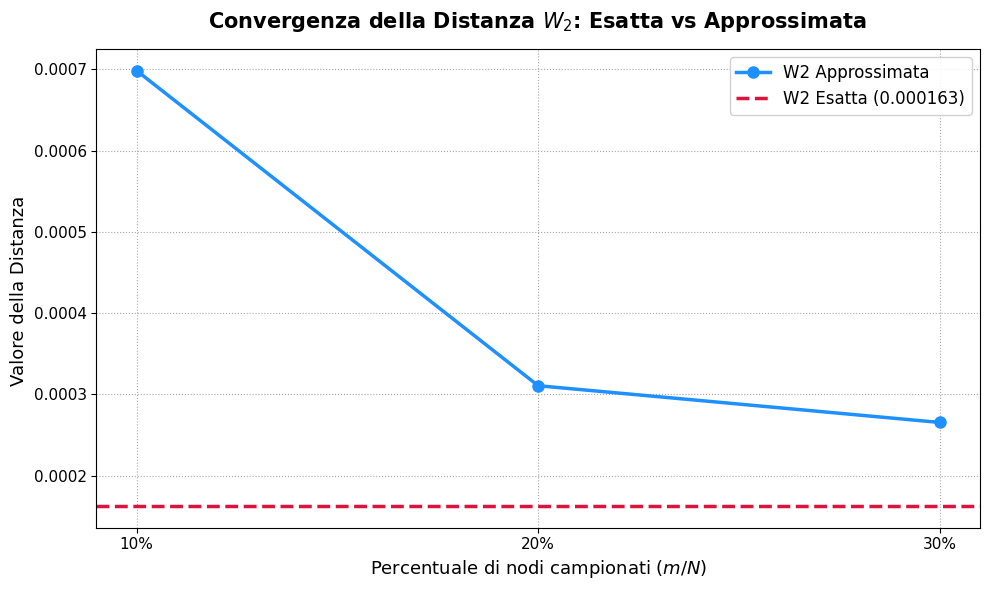

In [28]:

plt.figure(figsize=(10, 6))

# Plot della curva della distanza approssimata
plt.plot(percentuali, distanze_approssimate, marker='o', linestyle='-', color='dodgerblue', linewidth=2.5, markersize=8, label='W2 Approssimata')

# Plot della distanza esatta come linea orizzontale fissa
plt.axhline(y=dist_esatta, color='crimson', linestyle='--', linewidth=2.5, label=f'W2 Esatta ({dist_esatta:.6f})')

# Formattazione ed estetica
plt.title('Convergenza della Distanza $W_2$: Esatta vs Approssimata ', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Percentuale di nodi campionati ($m / N$)', fontsize=13)
plt.ylabel('Valore della Distanza ', fontsize=13)

# Rendi l'asse X più leggibile trasformando i decimali in formati percentuali (es. 10%)
plt.xticks(percentuali, [f"{int(p*100)}%" for p in percentuali], fontsize=11)
plt.yticks(fontsize=11)

# Aggiungi una griglia di supporto
plt.grid(True, linestyle=':', alpha=0.7, color='gray')
plt.legend(fontsize=12, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()